In [1]:
import os
import re
from pathlib import Path
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = Path(r"샘플데이터\Sample\01.원천데이터\1.모터_감속기")
OUTPUT_DIR = Path("샘플데이터/03.합성데이터/1.모터_감속기")


In [2]:
# 파일명 파싱: YY_MM_DD_hh_mm_ss_nn_zsplitnnn_nnn_SensorType.png
PATTERN = re.compile(
    r"^(\d{2}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})"   # timestamp
    r"_(\d{2})"                                    # sequential num
    r"_(zsplit\d{3})"                              # zsplit num
    r"_(\d{3})"                                    # split num
    r"_(.+)\.png$"                                 # sensor type
)

def parse_filename(fname):
    m = PATTERN.match(fname)
    if not m:
        return None
    ts, seq, zsplit, split_num, sensor = m.groups()
    return {
        "timestamp": ts,
        "seq": seq,
        "zsplit": zsplit,
        "split_num": int(split_num),
        "sensor": sensor,
        "group_key": f"{ts}_{seq}_{zsplit}_{sensor}",
    }


In [3]:
# 모든 PNG를 그룹키별로 수집
groups = defaultdict(list)  # group_key -> [(split_num, path), ...]

for png_path in sorted(BASE_DIR.rglob("*.png")):
    info = parse_filename(png_path.name)
    if info is None:
        continue
    groups[info["group_key"]].append((info["split_num"], png_path, info))

print(f"총 그룹 수: {len(groups)}")
print(f"총 파일 수: {sum(len(v) for v in groups.values())}")


총 그룹 수: 81
총 파일 수: 225


In [4]:
def merge_images_horizontal(image_paths):
    """이미지 리스트를 가로로 이어 붙임"""
    imgs = [Image.open(p) for p in image_paths]
    total_width = sum(img.width for img in imgs)
    max_height = max(img.height for img in imgs)
    merged = Image.new("RGB", (total_width, max_height), color=(255, 255, 255))
    x = 0
    for img in imgs:
        merged.paste(img, (x, 0))
        x += img.width
    return merged


def get_output_path(sample_info, sample_png_path):
    """원천데이터 경로 구조를 유지하면서 출력 경로 생성"""
    # sample_png_path: 01.원천데이터/1.모터_감속기/IONIQ/DEMAG/0728/Current_U/파일명.png
    rel = sample_png_path.relative_to(BASE_DIR)  # IONIQ/DEMAG/0728/Current_U/파일명.png
    subdir = rel.parent                            # IONIQ/DEMAG/0728/Current_U
    ts = sample_info["timestamp"]
    seq = sample_info["seq"]
    zsplit = sample_info["zsplit"]
    sensor = sample_info["sensor"]
    out_name = f"{ts}_{seq}_{zsplit}_merged_{sensor}.png"
    return OUTPUT_DIR / subdir / out_name


In [5]:
# 모든 그룹 처리 및 저장
for group_key, entries in groups.items():
    entries_sorted = sorted(entries, key=lambda x: x[0])  # split_num 순 정렬
    image_paths = [e[1] for e in entries_sorted]
    sample_info = entries_sorted[0][2]
    sample_path = entries_sorted[0][1]

    merged = merge_images_horizontal(image_paths)

    out_path = get_output_path(sample_info, sample_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    merged.save(out_path)

print("완료: 모든 그룹 이미지를 가로로 합쳐 저장했습니다.")
print(f"저장 위치: {OUTPUT_DIR}")


완료: 모든 그룹 이미지를 가로로 합쳐 저장했습니다.
저장 위치: 샘플데이터\03.합성데이터\1.모터_감속기


그룹: 22_07_28_12_15_20_01_zsplit005_Current_U
분할 수: 5개


C:\Users\kingm\AppData\Local\Temp\ipykernel_23808\3949251319.py:16: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kingm\AppData\Local\Temp\ipykernel_23808\3949251319.py:16: UserWarning: Glyph 54624 (\N{HANGUL SYLLABLE HAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kingm\AppData\Local\Temp\ipykernel_23808\3949251319.py:16: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kingm\AppData\Local\Temp\ipykernel_23808\3949251319.py:16: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kingm\AppData\Local\Temp\ipykernel_23808\3949251319.py:16: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kingm\AppData\Local\Temp\ipykernel_23808\3949251319.py:16: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing

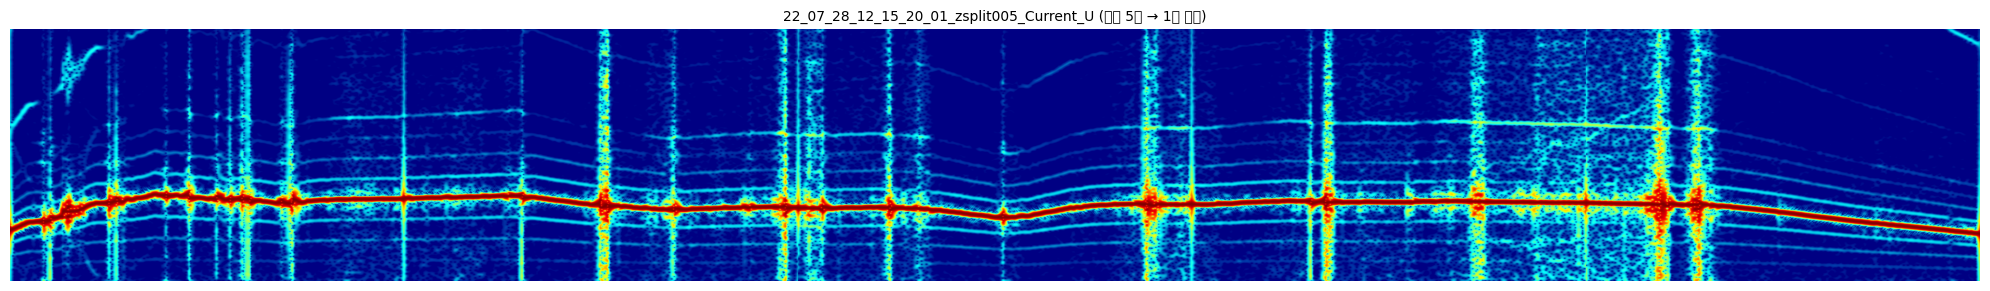

In [6]:
# 결과 미리보기 (그룹 1개 예시)
sample_key = next(iter(groups))
sample_entries = sorted(groups[sample_key], key=lambda x: x[0])
sample_paths = [e[1] for e in sample_entries]
sample_info = sample_entries[0][2]

print(f"그룹: {sample_key}")
print(f"분할 수: {len(sample_paths)}개")

merged_preview = merge_images_horizontal(sample_paths)

fig, ax = plt.subplots(figsize=(min(len(sample_paths) * 5, 20), 3))
ax.imshow(merged_preview)
ax.axis("off")
ax.set_title(f"{sample_key} (분할 {len(sample_paths)}개 → 1행 합성)", fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# 샘플 한 줄 이미지 -> 시계열 변환: 준비
import numpy as np
import pandas as pd

TS_OUTPUT_DIR = Path("샘플데이터/03.합성데이터/1.모터_감속기_시계열")
TS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [8]:
# 샘플 한 줄 이미지 -> 시계열 변환: 특징 추출 함수

def image_to_energy_map(image):
    """RGB 스펙트로그램 이미지를 0~1 범위의 에너지 맵으로 변환"""
    arr = np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0
    energy = np.sqrt(np.mean(arr ** 2, axis=2))
    energy = (energy - energy.min()) / (energy.max() - energy.min() + 1e-8)
    return energy


def extract_timeseries_from_spectrogram(
    image,
    threshold_percentile=90,
    min_band_height=2,
    freq_from_bottom=True,
):
    """
    한 줄 합성 스펙트로그램에서 시간별 핵심 특징을 추출한다.

    반환 컬럼:
    - time_idx: x축 시간 인덱스
    - peak_freq_bin: 해당 시간에서 에너지가 가장 큰 주파수 bin
    - band_start, band_end: 임계치 이상 영역의 주파수 범위
    - rms: 해당 시간 컬럼의 RMS 에너지
    """
    energy = image_to_energy_map(image)
    height, width = energy.shape
    threshold = np.percentile(energy, threshold_percentile)

    rows = []
    for x in range(width):
        column = energy[:, x]
        active_y = np.where(column >= threshold)[0]
        rms = float(np.sqrt(np.mean(column ** 2)))

        if len(active_y) >= min_band_height:
            peak_y = int(np.argmax(column))

            if freq_from_bottom:
                active_bins = height - 1 - active_y
                peak_freq_bin = height - 1 - peak_y
            else:
                active_bins = active_y
                peak_freq_bin = peak_y

            band_start = int(active_bins.min())
            band_end = int(active_bins.max())
        else:
            peak_freq_bin = np.nan
            band_start = np.nan
            band_end = np.nan

        rows.append({
            "time_idx": x,
            "peak_freq_bin": peak_freq_bin,
            "band_start": band_start,
            "band_end": band_end,
            "rms": rms,
        })

    return pd.DataFrame(rows), energy, threshold


def add_sample_metadata(ts_df, sample_key, sample_paths, sample_info):
    """추출된 시계열에 그룹/차량/결함/날짜/센서 메타데이터를 붙인다."""
    rel_parts = sample_paths[0].relative_to(BASE_DIR).parts
    vehicle, fault_class, date, sensor = rel_parts[:4]

    result = ts_df.copy()
    result.insert(0, "group_key", sample_key)
    result.insert(1, "vehicle", vehicle)
    result.insert(2, "fault_class", fault_class)
    result.insert(3, "date", date)
    result.insert(4, "sensor", sensor)
    result.insert(5, "split_count", len(sample_paths))
    result.insert(6, "timestamp", sample_info["timestamp"])
    result.insert(7, "zsplit", sample_info["zsplit"])
    return result


In [9]:
# 샘플 한 줄 이미지 -> 시계열 변환: 실행 및 저장
threshold_percentile = 90
min_band_height = 2

sample_ts_df, sample_energy_map, sample_threshold = extract_timeseries_from_spectrogram(
    merged_preview,
    threshold_percentile=threshold_percentile,
    min_band_height=min_band_height,
    freq_from_bottom=True,
)

sample_ts_df = add_sample_metadata(sample_ts_df, sample_key, sample_paths, sample_info)

csv_path = TS_OUTPUT_DIR / f"{sample_key}_timeseries.csv"
sample_ts_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"시계열 행 수: {len(sample_ts_df):,}")
print(f"임계치 분위수: 상위 {100 - threshold_percentile}% 영역")
print(f"실제 임계치: {sample_threshold:.4f}")
print(f"저장 위치: {csv_path}")

sample_ts_df.head()


시계열 행 수: 10,000
임계치 분위수: 상위 10% 영역
실제 임계치: 0.7696
저장 위치: 03.합성데이터\1.모터_감속기_시계열\22_07_28_12_15_20_01_zsplit005_Current_U_timeseries.csv


,group_key,vehicle,fault_class,date,sensor,split_count,timestamp,zsplit,time_idx,peak_freq_bin,band_start,band_end,rms
0,22_07_28_12_15_20_01_zsplit005_Current_U,IONIQ,DEMAG,0728,Current_U,5,22_07_28_12_15_20,zsplit005,0,790,0,1279,0.798971
1,22_07_28_12_15_20_01_zsplit005_Current_U,IONIQ,DEMAG,0728,Current_U,5,22_07_28_12_15_20,zsplit005,1,791,0,1279,0.789968
2,22_07_28_12_15_20_01_zsplit005_Current_U,IONIQ,DEMAG,0728,Current_U,5,22_07_28_12_15_20,zsplit005,2,336,0,798,0.774595
3,22_07_28_12_15_20_01_zsplit005_Current_U,IONIQ,DEMAG,0728,Current_U,5,22_07_28_12_15_20,zsplit005,3,576,0,797,0.754943
4,22_07_28_12_15_20_01_zsplit005_Current_U,IONIQ,DEMAG,0728,Current_U,5,22_07_28_12_15_20,zsplit005,4,543,0,796,0.733967


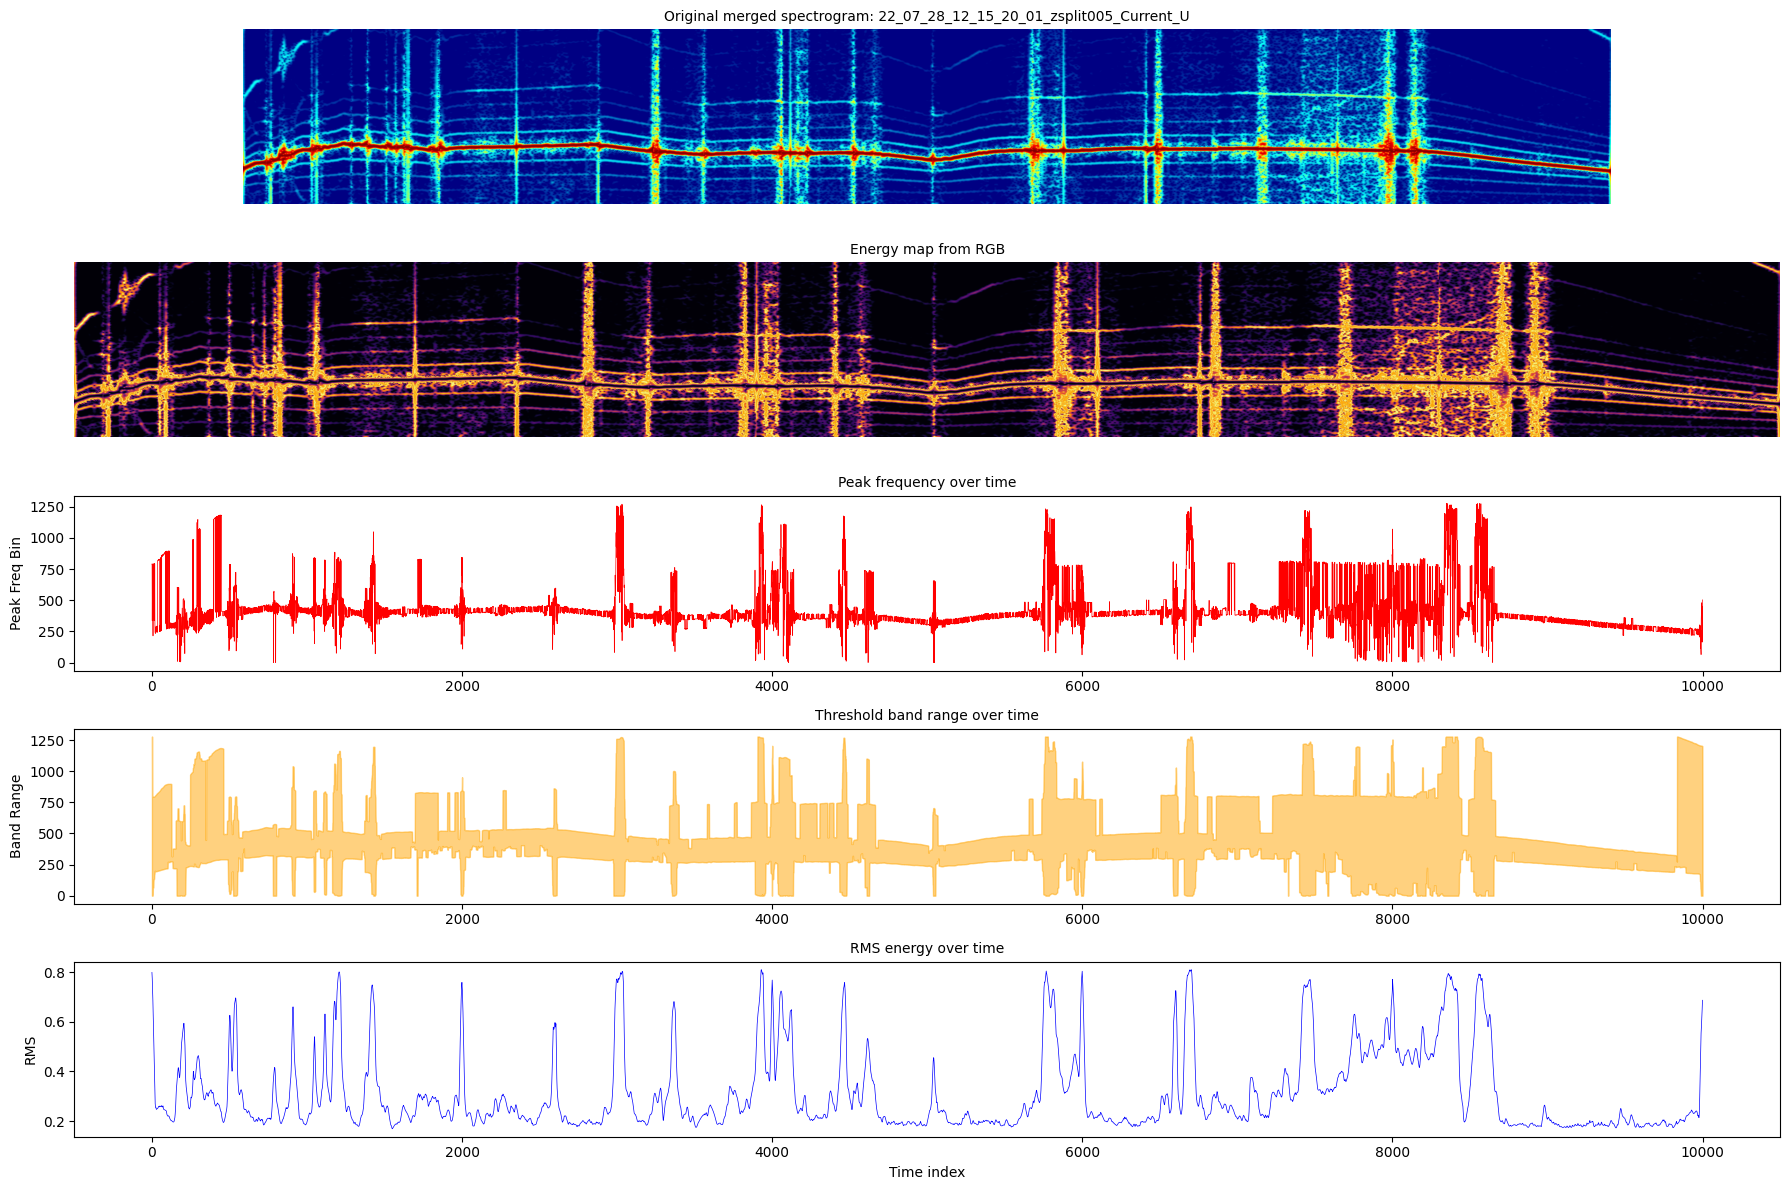

In [10]:
# 샘플 한 줄 이미지 -> 시계열 변환: 원본/에너지맵/추출 결과 검증 시각화
fig, axes = plt.subplots(5, 1, figsize=(18, 12), sharex=False)

axes[0].imshow(merged_preview)
axes[0].set_title(f"Original merged spectrogram: {sample_key}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(sample_energy_map, cmap="inferno", aspect="auto")
axes[1].set_title("Energy map from RGB", fontsize=10)
axes[1].axis("off")

plot_df = sample_ts_df

axes[2].plot(plot_df["time_idx"], plot_df["peak_freq_bin"], linewidth=0.5, color="red")
axes[2].set_ylabel("Peak Freq Bin")
axes[2].set_title("Peak frequency over time", fontsize=10)

valid_band = plot_df.dropna(subset=["band_start", "band_end"])
axes[3].fill_between(
    valid_band["time_idx"],
    valid_band["band_start"],
    valid_band["band_end"],
    alpha=0.5,
    color="orange",
)
axes[3].set_ylabel("Band Range")
axes[3].set_title("Threshold band range over time", fontsize=10)

axes[4].plot(plot_df["time_idx"], plot_df["rms"], linewidth=0.5, color="blue")
axes[4].set_ylabel("RMS")
axes[4].set_xlabel("Time index")
axes[4].set_title("RMS energy over time", fontsize=10)

plt.tight_layout()
plt.show()
